在图像中寻找圆
1、二值化、形态学、blob检测
2、轮廓检测和椭圆拟合发方法

In [1]:
import matplotlib.pyplot as plt
import cv2 
import numpy as np

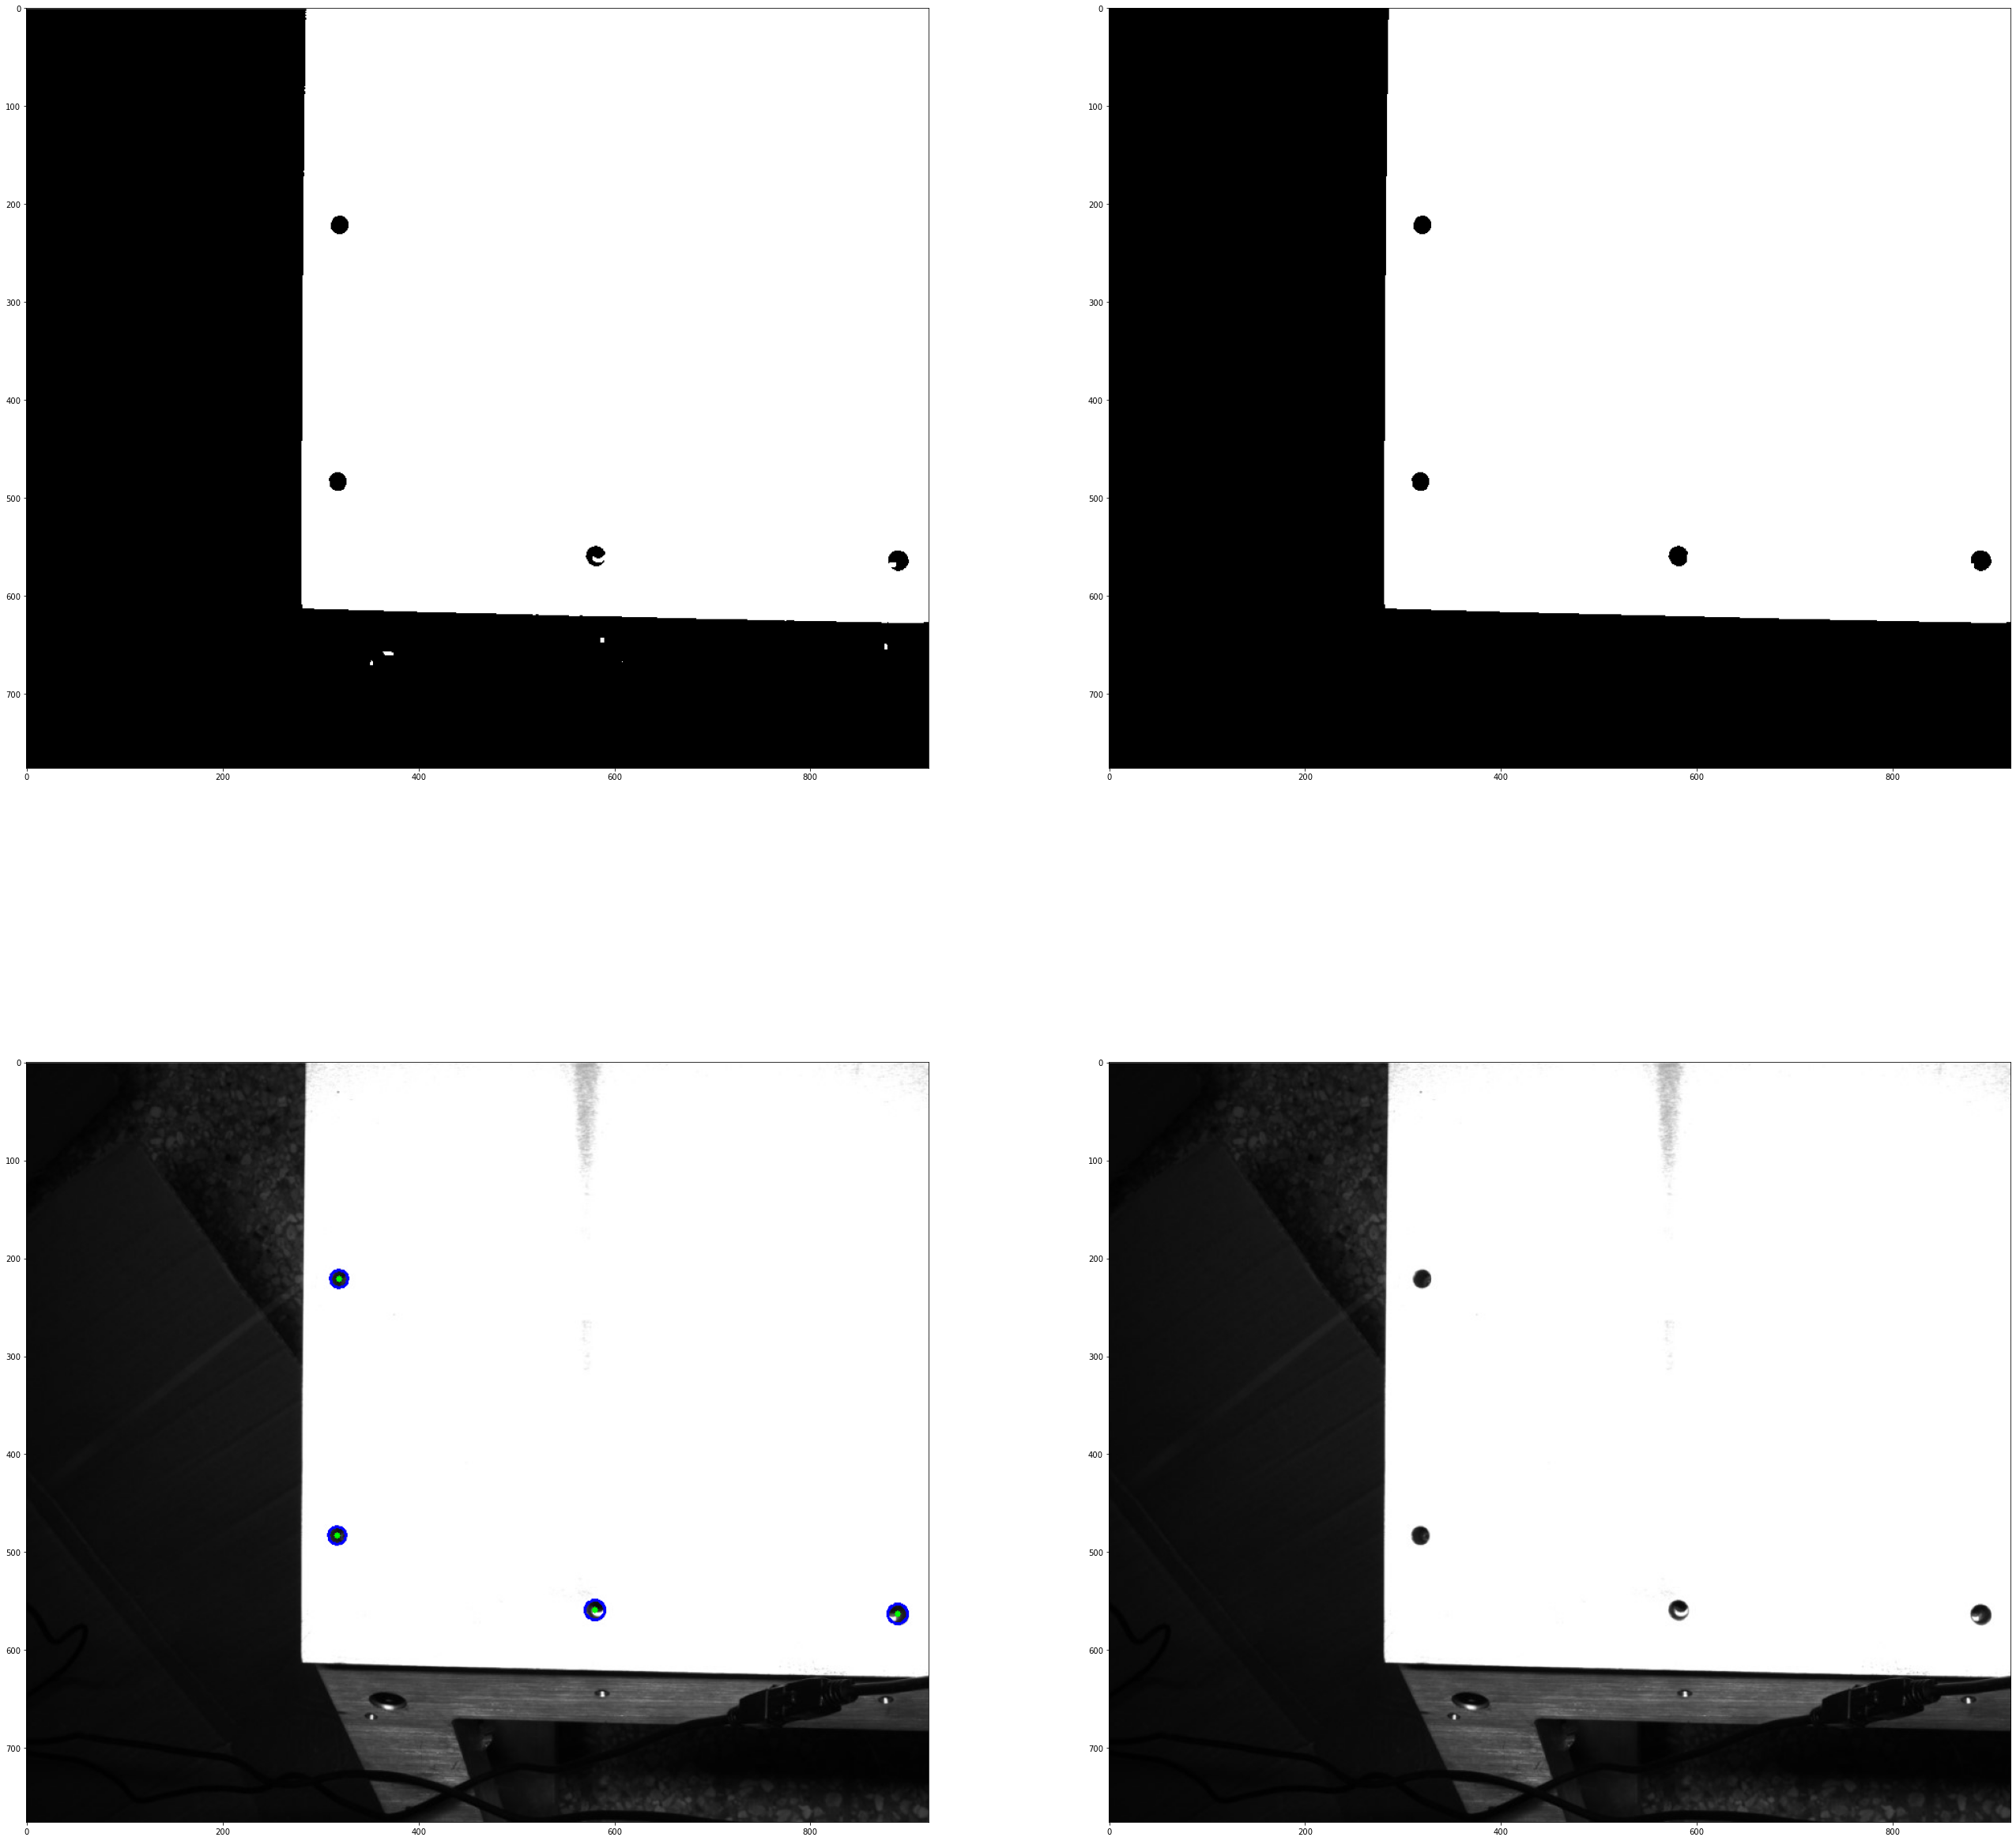

In [27]:
image = cv2.imread("./images/circle.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
ret, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
se = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 13))
binary_se = cv2.morphologyEx(binary, cv2.MORPH_OPEN, se) # 形态学开操作

params = cv2.SimpleBlobDetector_Params()
detector = cv2.SimpleBlobDetector.create(params)
keypoints = detector.detect(binary_se) # 关键点检测
blob_info = []
image_copy = image.copy() # 画出结果
for kp in keypoints:
    cv2.circle(image_copy, (np.int(kp.pt[0]), np.int(kp.pt[1])), 3, (0, 255, 0), -1, 8) # 画圆心
    cv2.circle(image_copy, (np.int(kp.pt[0]), np.int(kp.pt[1])), np.int(kp.size/2), (0, 0, 255), 2, 2)
plt.figure(figsize=(45,45))
plt.subplot(2,2,1)
plt.imshow(binary, cmap='gray')
plt.subplot(2,2,2)
plt.imshow(binary_se, cmap='gray')
plt.subplot(2,2,3)
plt.imshow(image_copy)
plt.subplot(2,2,4)
plt.imshow(image)
plt.show()


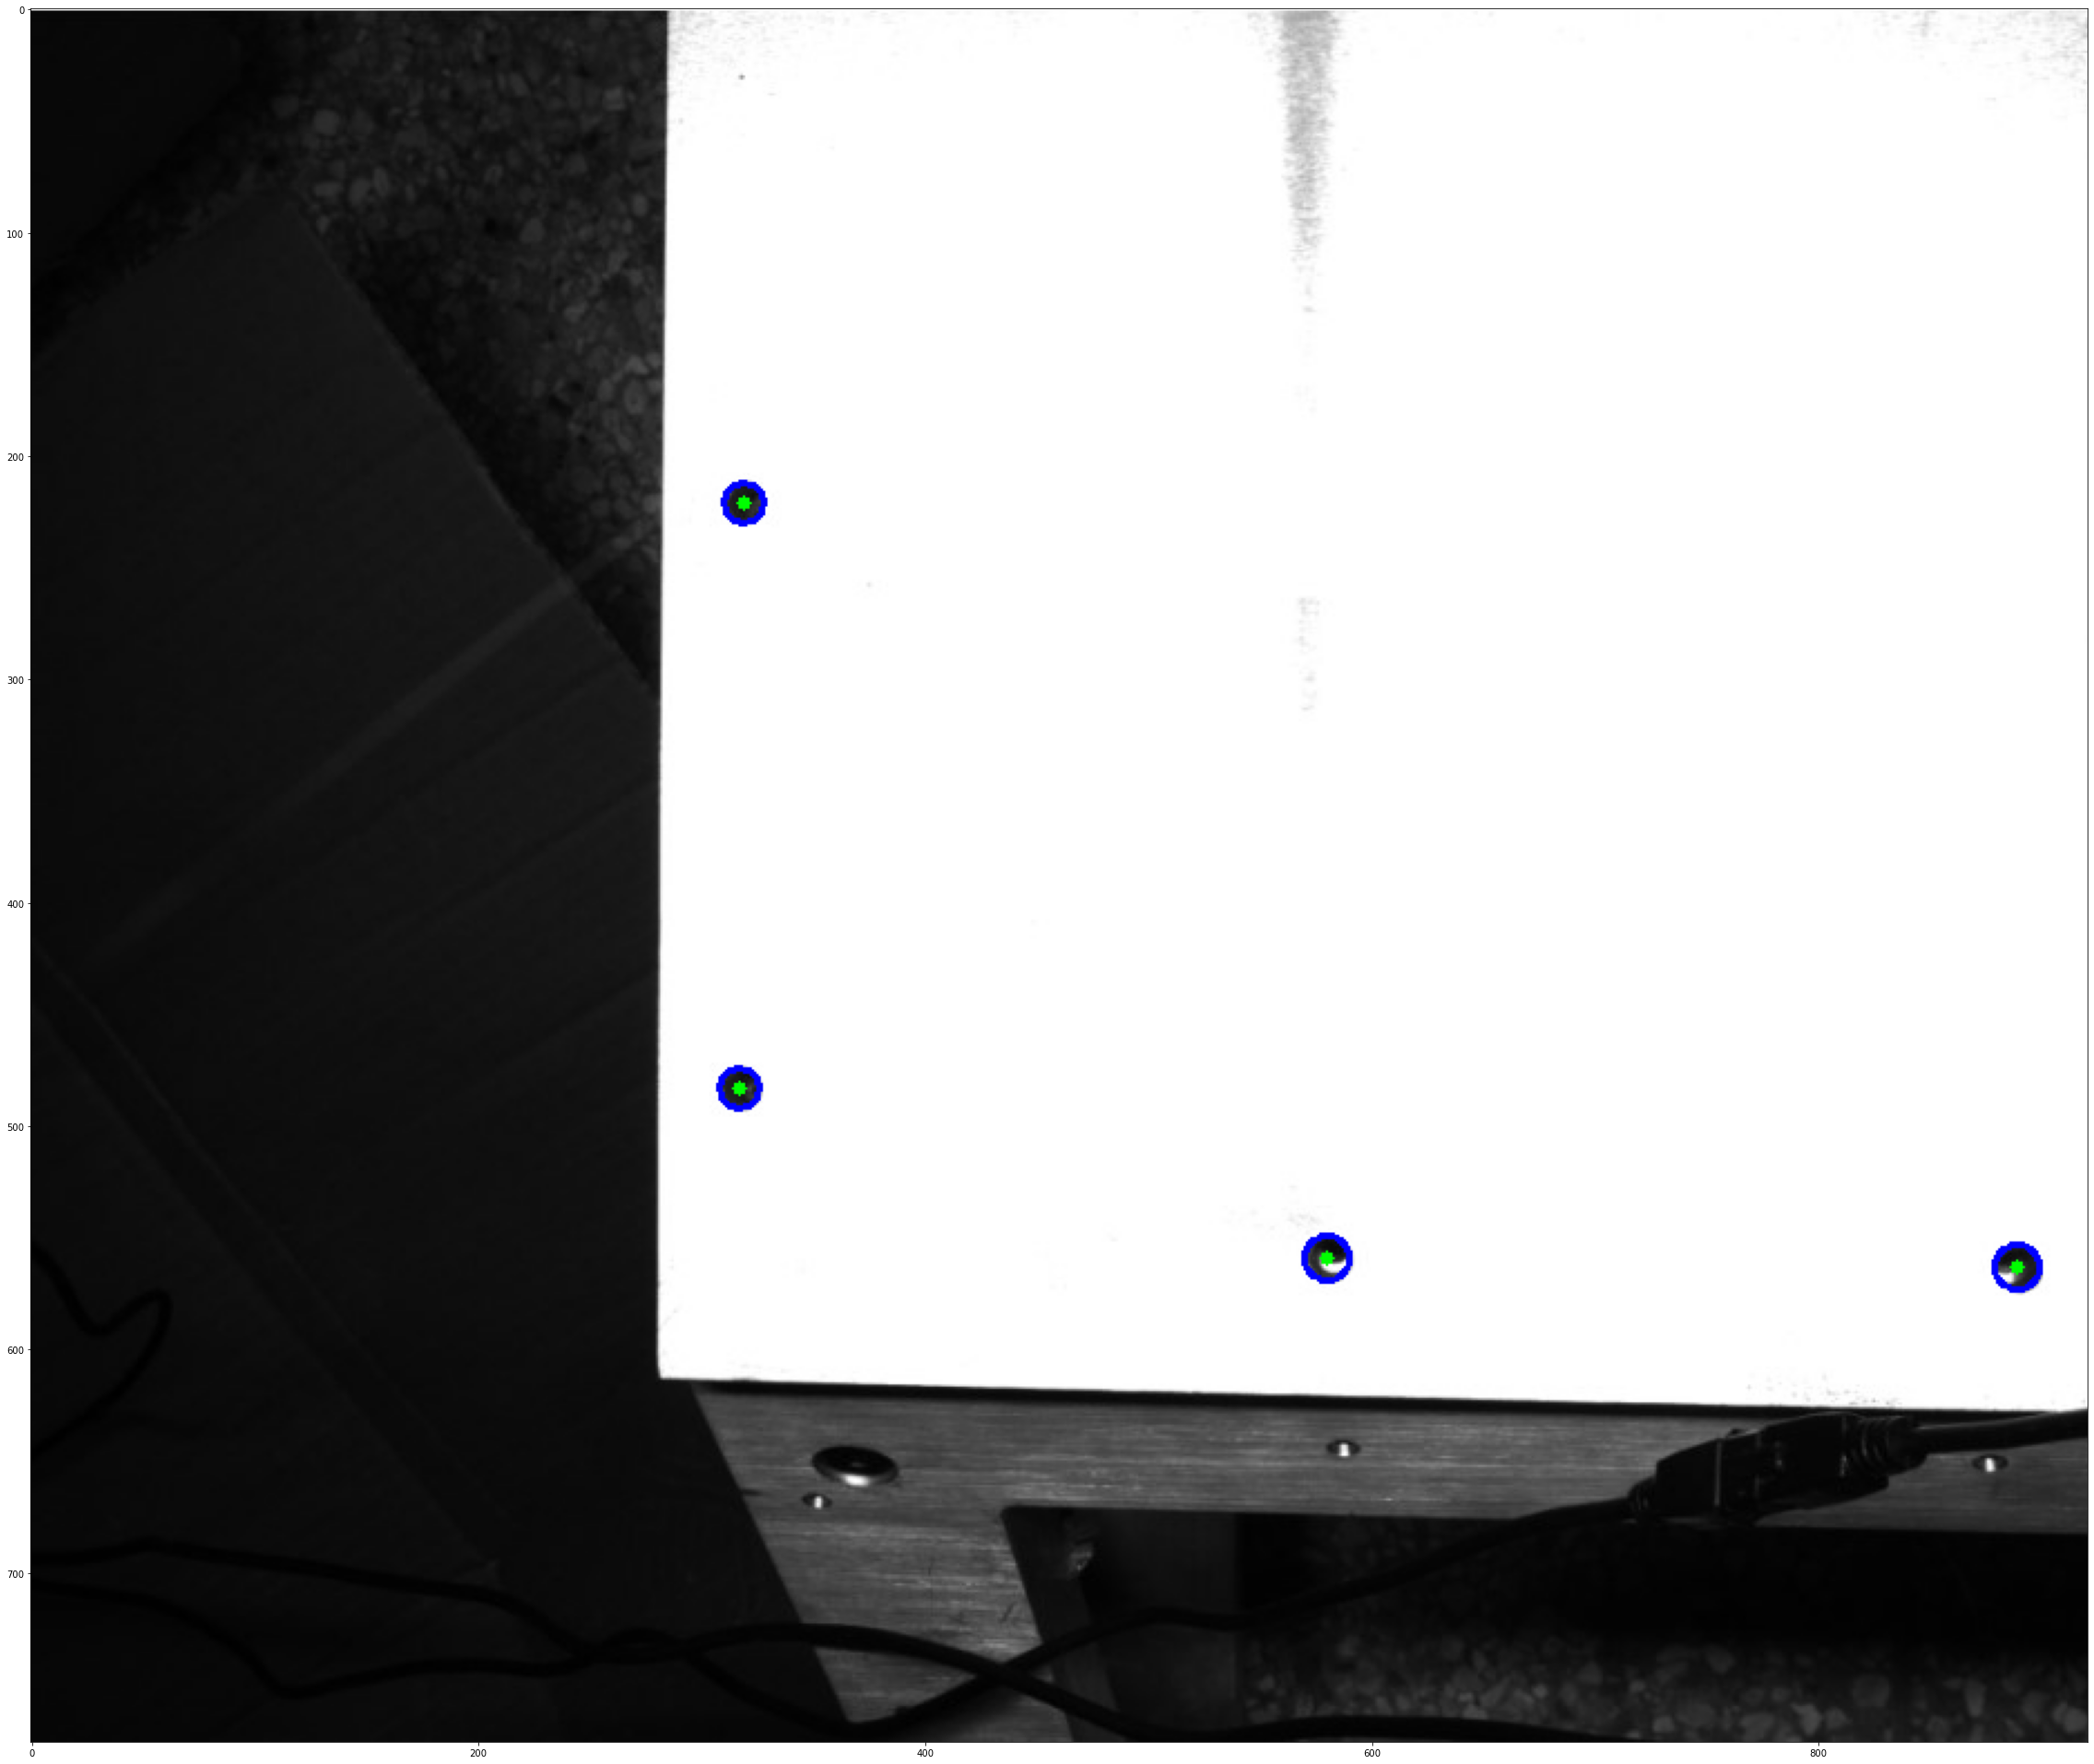

In [28]:
plt.figure(figsize=(40,40))
plt.imshow(image_copy)
plt.show()

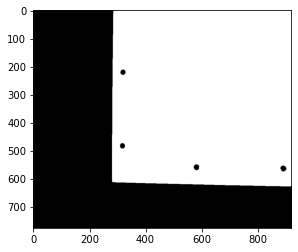

In [13]:
image2 = cv2.imread("./images/circle.jpg")
gray2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)
ret, binary2 = cv2.threshold(gray2, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
se = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 13))
binary_se2 = cv2.morphologyEx(binary2, cv2.MORPH_OPEN, se) # 形态学开操作
plt.imshow(binary_se2, cmap='gray')
plt.show()

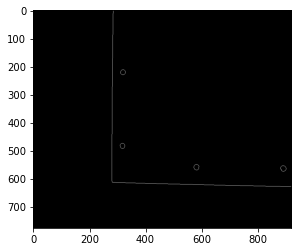

In [14]:
img2 = cv2.Laplacian(binary_se2, -1)
plt.imshow(img2, cmap='gray')
plt.show()

In [15]:
#找轮廓并排序
contours, hierarchy	= cv2.findContours(img2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

contours_size = np.array([len(s) for s in contours ])
sort_index = np.argsort(-contours_size) #返回从大到小的索引,降序排列
idx = sort_index[0] #取一个轮廓
print(len(contours))

5


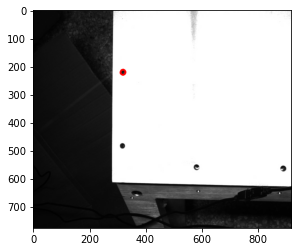

In [20]:
# 绘制轮廓，找到想要的轮廓
idx = sort_index[4]
src_img = image2.copy()
cv2.drawContours(src_img, contours, idx, (255,0,0), thickness=5) #画原轮廓，绿色
plt.imshow(src_img)
plt.show()

In [21]:
# 拟合椭圆
ellipse_s = []
for i in range(1,5):
    idx = sort_index[i] # 取椭圆的轮廓索引出来
    ellipse_s.append(cv2.fitEllipse(contours[idx]))

In [22]:
# 画拟合椭圆的外接旋转矩形
from myContoursAnalyze import ContoursCommonHelper

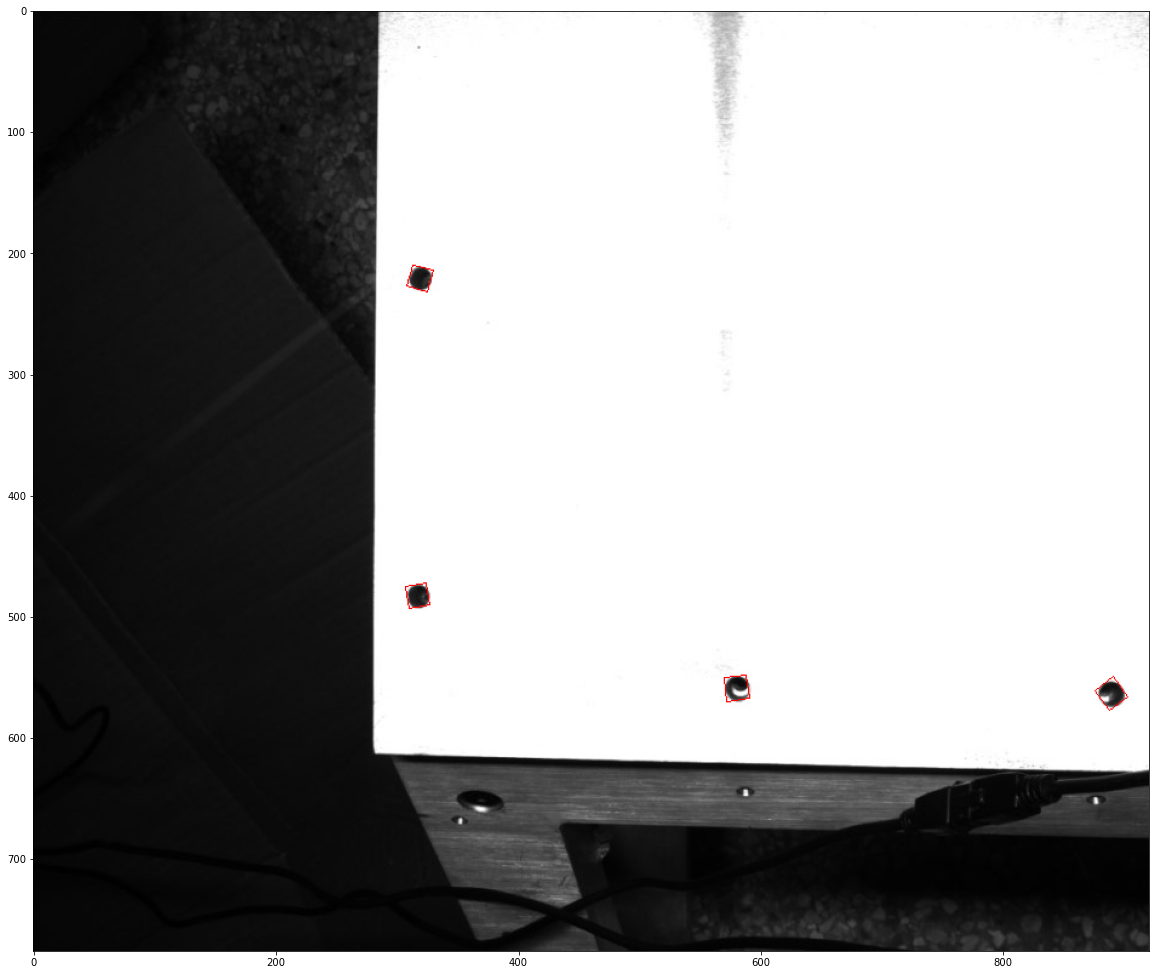

In [25]:
image2_copy = image2.copy()
for rect in ellipse_s:
    ContoursCommonHelper.drawRotateRectCV(image2_copy, rect, color=(255,0,0), thickness=1)
plt.figure(figsize=(20,20))
plt.imshow(image2_copy)
plt.show()